In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.cm import get_cmap
from scipy.special import roots_gegenbauer
import matplotlib
import matplotlib.dates as mdates 
from scipy.special import eval_gegenbauer
import datetime

# Gegenbauer polynomials : weighing functions

/tmp/ipykernel_4164/3671467296.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("coolwarm")
/tmp/ipykernel_4164/3671467296.py:16: RuntimeWarning: divide by zero encountered in power
  w = (1 - x**2)**(a - 0.5)


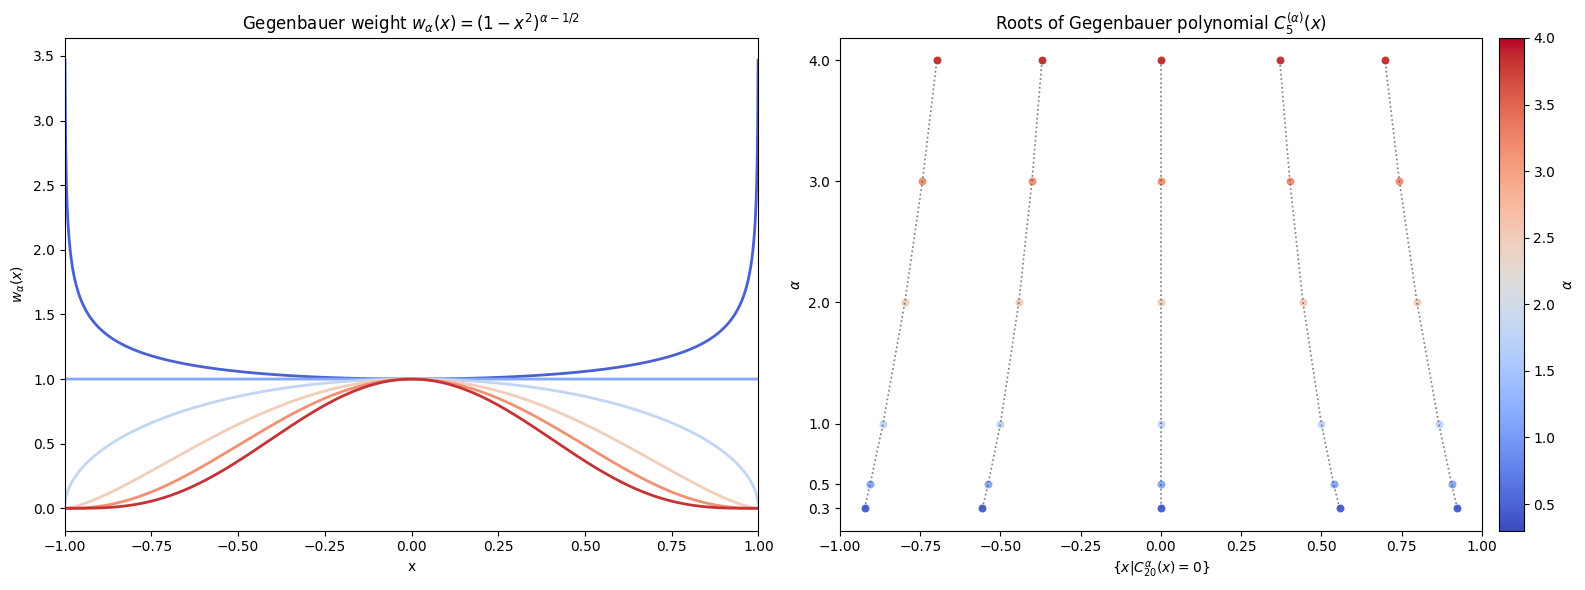

In [2]:
# Parameters
alphas = np.array([0.3, 0.5, 1.0, 2.0, 3.0, 4.0], dtype=float)
n = 5  # degree for showing root locations

# Grid on [-1,1]
x = np.linspace(-1, 1, 2001)

# Colormap
cmap = get_cmap("coolwarm")
colors = cmap(np.linspace(0.05, 0.95, len(alphas)))

fig, (ax_w, ax_r) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Weight functions: w_alpha(x) = (1-x^2)^(alpha-1/2) ----
for a, c in zip(alphas, colors):
    w = (1 - x**2)**(a - 0.5)
    ax_w.plot(x, w, lw=2, color=c, label=fr"$\alpha={a:g}$")

ax_w.set_title(r"Gegenbauer weight $w_\alpha(x)=(1-x^2)^{\alpha-1/2}$")
ax_w.set_xlabel("x")
ax_w.set_ylabel(r"$w_\alpha(x)$")
ax_w.set_xlim(-1, 1)
# ax_w.set_yscale("log")  # highlights endpoint behavior
# ax_w.grid(True, alpha=0.3)
# ax_w.legend(frameon=False)

# ---- Root distributions for C_n^(alpha) ----
# Store roots so we can connect same-index roots across alphas
roots_by_alpha = []
for a in alphas:
    r, _ = roots_gegenbauer(n, a)
    roots_by_alpha.append(r)
roots_by_alpha = np.vstack(roots_by_alpha)  # shape: (len(alphas), n)

# Scatter of roots for each alpha
for a, c, r in zip(alphas, colors, roots_by_alpha):
    ax_r.scatter(r, np.full_like(r, a), s=22, color=c)

# Dotted "tracks": connect root k across alpha values
# (these show how each root moves as alpha increases)
for k in range(n):
    ax_r.plot(roots_by_alpha[:, k], alphas, ls=":", lw=1.2, color="0.35", alpha=0.8)

ax_r.set_title(fr"Roots of Gegenbauer polynomial $C_{{{n}}}^{{(\alpha)}}(x)$")
ax_r.set_xlabel(r"$\left\{ x | C_{20}^{\alpha}(x) = 0 \right\}$")
ax_r.set_ylabel(r"$\alpha$")
ax_r.set_xlim(-1, 1)
ax_r.set_yticks(alphas)
# ax_r.grid(True, alpha=0.3)

# Optional: colorbar to emphasize mapping alpha<->color
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=alphas.min(), vmax=alphas.max())
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_r, fraction=0.05, pad=0.025)
cbar.set_label(r"$\alpha$")

plt.tight_layout()
plt.savefig('./gegenbauer_roots_weights.png', dpi = 300, transparent = True, bbox_inches ='tight')

# Gegenbauer decomposition of the liquidity curve

In [126]:
def gegenbauer_vander(x, deg, alpha):
    if alpha <= -0.5:
        raise ValueError("Require alpha > -0.5.")
    x = np.asarray(x, float)
    return np.column_stack([eval_gegenbauer(n, alpha, x) for n in range(deg + 1)])

def orthopoly_decompose(
    Ylog,                 # array-like (n_t, n_ticks) OR pd.DataFrame with tick columns
    x_norm,               # array-like (n_ticks,), must be in [-1, 1]
    deg=5,                # highest degree; number of factors = deg+1
    center_time=True,     # subtract m(x) across time (like PCA centering)
    ridge=1e-10,          # small ridge for numerical stability
    index=None, 
    alpha = 0.5,          # optional time index if Ylog is ndarray
):
    if isinstance(Ylog, pd.DataFrame):
        Y = Ylog.to_numpy(dtype=float)
        if index is None:
            index = Ylog.index
    else:
        Y = np.asarray(Ylog, dtype=float)
        if index is None:
            index = pd.RangeIndex(Y.shape[0])

    x = np.asarray(x_norm, dtype=float)
    if np.any(x < -1 - 1e-12) or np.any(x > 1 + 1e-12):
        raise ValueError("x_norm must lie in [-1,1].")

    n_t, n_ticks = Y.shape
    if x.shape[0] != n_ticks:
        raise ValueError("x_norm length must match n_ticks (number of columns in Ylog).")

    # --- mean curve and centering (matches the paper's 'centered data' assumption)
    if center_time:
        m = Y.mean(axis=0)
        X = Y - m
    else:
        m = np.zeros(n_ticks)
        X = Y

    
    Phi = gegenbauer_vander(x, deg, alpha)   # (n_ticks, deg+1)
    basis_name = f"Gegenbauer_{alpha}"

    # --- solve for coefficients B in least squares sense for all t:
    # X ≈ B Phi^T  ->  B = X Phi (Phi^T Phi)^{-1}
    G = Phi.T @ Phi
    G = G + ridge * np.eye(G.shape[0])
    Ginv = np.linalg.inv(G)

    B = (X @ Phi) @ Ginv               # (n_t, deg+1)
    Yhat = (B @ Phi.T) + m             # (n_t, n_ticks)
    R = Y - Yhat

    # package coefficients as DataFrame for convenient "score through time"
    cols = [f"{basis_name}_deg{j}" for j in range(deg + 1)]
    B_df = pd.DataFrame(B, index=index, columns=cols)

    return m, B_df, Phi, Yhat, R

def gegenbauer_scores(Ylog, x_norm, deg=5, alpha=0.5, center_time=True, ridge=1e-10):
    mG, B_gegen, Phi_gegen, Yhat_gegen, R_gegen = orthopoly_decompose(
        Ylog, x_norm, deg=deg, center_time=center_time, ridge=ridge, alpha=alpha
    )
    return B_gegen, Yhat_gegen, R_gegen, mG, Phi_gegen

def plot_shocks(gegen_scores, m, phi, Ylog, alpha, i):
    fig, axs = plt.subplots(3,2, figsize=(12, 12))
    bs = gegen_scores.iloc[-1,:].values
    std = gegen_scores.std(axis = 0).values
    for k in range(6):
        axs[k//2, k%2].plot(bs @ phi.T + m, color = matplotlib.cm.coolwarm(np.linspace(0,1,5)[i]+0.2), lw=2, label = 'Yhat')
        bsp = bs.copy()
        bsp[k]+=std[k]  
        axs[k//2, k%2].plot(bsp @ phi.T + m, color = matplotlib.cm.coolwarm(np.linspace(0,1,5)[i] + 0.4), lw=2, label = '+1 std')
        bsp[k]-=2*std[k]  
        axs[k//2, k%2].plot(bsp @ phi.T + m, color = matplotlib.cm.coolwarm(np.linspace(0,1,5)[i]), lw=2, label = '-1 std')
        axs[k//2, k%2].plot(Ylog.iloc[-1,:].values, '--', alpha=0.5, label = 'Actual', color = 'black')
        axs[k//2, k%2].set_title(r'Shock $\beta_{}$'.format(k), fontsize = 10)
    plt.legend(ncols=4, frameon=False, bbox_to_anchor=(0.5, -0.2))
    fig.suptitle(r'Gegenbauer Basis Shocks ($\alpha={}$)'.format(alpha), fontsize = 14)
    plt.savefig(f'./gegenbauer_shocks_alpha{alpha}.png', dpi=300, transparent = True, bbox_inches = 'tight')


In [133]:
import numpy as np
import pandas as pd
from scipy.special import eval_gegenbauer


def gegenbauer_vander(x, deg, alpha, normalize=True, endpoint_eps=1e-10):
    """
    Construct a Gegenbauer basis on x.

    Returns
    -------
    Phi : ndarray
        Shape (n_ticks, deg + 1).
    """
    if alpha <= -0.5:
        raise ValueError("Require alpha > -0.5.")

    x = np.asarray(x, dtype=float)

    Phi = np.column_stack([
        eval_gegenbauer(k, alpha, x)
        for k in range(deg + 1)
    ])

    if normalize:
        # Gegenbauer weight:
        # w_alpha(x) = (1 - x^2)^(alpha - 1/2)
        #
        # Clip the endpoints because the weight is singular when
        # alpha < 1/2, although the singularity is integrable.
        base = np.clip(1.0 - x**2, endpoint_eps, None)
        w = base ** (alpha - 0.5)

        # Discrete weighted normalization
        norms = np.sqrt(np.sum(w[:, None] * Phi**2, axis=0))
        Phi = Phi / norms[None, :]

    return Phi


def gegenbauer_weight(
    x,
    alpha,
    endpoint_eps=1e-10,
    use_trapezoid_weights=True
):
    """
    Construct discrete Gegenbauer weights.

    The optional trapezoid weights approximate the continuous
    Gegenbauer inner product on a nonuniform grid.
    """
    x = np.asarray(x, dtype=float)

    if alpha <= -0.5:
        raise ValueError("Require alpha > -0.5.")

    if np.any(x < -1) or np.any(x > 1):
        raise ValueError("x must lie in [-1, 1].")

    # Gegenbauer spatial weight
    base = np.clip(1.0 - x**2, endpoint_eps, None)
    w_alpha = base ** (alpha - 0.5)

    if use_trapezoid_weights:
        # Numerical integration weights for the x-grid
        q = np.zeros_like(x)

        q[1:-1] = 0.5 * (x[2:] - x[:-2])
        q[0] = 0.5 * (x[1] - x[0])
        q[-1] = 0.5 * (x[-1] - x[-2])

        weights = q * w_alpha
    else:
        # Purely discrete weighted least squares
        weights = w_alpha

    # Normalize to improve numerical conditioning.
    weights = weights / np.mean(weights)

    return weights


def orthopoly_decompose_weighted(
    Ylog,
    x_norm,
    deg=5,
    center_time=True,
    ridge=1e-10,
    index=None,
    alpha=0.5,
    normalize_basis=True,
    use_trapezoid_weights=True
):
    """
    Weighted Gegenbauer decomposition.

    Fits:
        X_t(x) ~= sum_k beta[t, k] * Phi_k(x)

    using the weighted objective:
        sum_i w_alpha(x_i) * residual[t, i]^2
    """

    if isinstance(Ylog, pd.DataFrame):
        Y = Ylog.to_numpy(dtype=float)

        if index is None:
            index = Ylog.index

    else:
        Y = np.asarray(Ylog, dtype=float)

        if index is None:
            index = pd.RangeIndex(Y.shape[0])

    x = np.asarray(x_norm, dtype=float)

    if Y.ndim != 2:
        raise ValueError("Ylog must be two-dimensional.")

    n_t, n_ticks = Y.shape

    if len(x) != n_ticks:
        raise ValueError(
            "x_norm length must equal the number of columns in Ylog."
        )

    if np.any(~np.isfinite(Y)):
        raise ValueError("Ylog contains NaN or infinite values.")

    # Center across time
    if center_time:
        m = Y.mean(axis=0)
        X = Y - m
    else:
        m = np.zeros(n_ticks)
        X = Y.copy()

    # Gegenbauer basis
    Phi = gegenbauer_vander(
        x,
        deg=deg,
        alpha=alpha,
        normalize=normalize_basis
    )

    # Gegenbauer weights
    weights = gegenbauer_weight(
        x,
        alpha=alpha,
        use_trapezoid_weights=use_trapezoid_weights
    )

    # Weighted Gram matrix:
    #
    # G = Phi.T @ W @ Phi
    #
    weighted_Phi = weights[:, None] * Phi
    G = Phi.T @ weighted_Phi

    # Ridge stabilization
    if ridge > 0:
        G = G + ridge * np.eye(deg + 1)

    # Weighted cross-product:
    #
    # X @ W @ Phi
    #
    X_weighted_Phi = X @ weighted_Phi

    # Solve for beta without explicitly inverting G
    B = np.linalg.solve(
        G,
        X_weighted_Phi.T
    ).T

    # Reconstruction
    Yhat = B @ Phi.T + m

    # Residuals
    R = Y - Yhat

    basis_name = f"Gegenbauer_{alpha}"

    cols = [
        f"{basis_name}_deg{k}"
        for k in range(deg + 1)
    ]

    B_df = pd.DataFrame(
        B,
        index=index,
        columns=cols
    )

    return m, B_df, Phi, Yhat, R, weights


def gegenbauer_scores_weighted(
    Ylog,
    x_norm,
    deg=5,
    alpha=0.5,
    center_time=True,
    ridge=1e-10,
    normalize_basis=True,
    use_trapezoid_weights=True
):
    """
    Convenience wrapper matching your current API.
    """

    m, scores, Phi, Yhat, R, weights = (
        orthopoly_decompose_weighted(
            Ylog=Ylog,
            x_norm=x_norm,
            deg=deg,
            alpha=alpha,
            center_time=center_time,
            ridge=ridge,
            normalize_basis=normalize_basis,
            use_trapezoid_weights=use_trapezoid_weights
        )
    )

    return scores, Yhat, R, m, Phi, weights

In [131]:
df = pd.read_parquet('hourly_liquidity_full.parquet')

def preprocess_liq_curve(df, TT = datetime.datetime(2023,1,1,0, tzinfo=datetime.timezone.utc)):
    d = df[df.hour >= TT]
    # d = d[d.hour <= TT_end]
    d["timestamp"] = pd.to_datetime(d["timestamp"], utc=True, unit = 's')
    WINDOW = 50
    d["tick_norm"] = (d["tickLower"].astype(float) - 0.0) / WINDOW
    d["tick_norm"] = d["tick_norm"].clip(-1, 1)

    # Log liquidity (use log1p to handle zeros)
    d["logL"] = np.log1p(d["active_liquidity_L"].astype(float))

    LIQ_COL = "active_liquidity_L"            
    Y_pegcentered = (d.pivot_table(index="timestamp", columns="tick_norm", values=LIQ_COL, aggfunc="sum")
        .sort_index()
        .sort_index(axis=1))
    Y_pegcentered = Y_pegcentered.fillna(0.0)
    Ylog_pegcentered = np.log1p(Y_pegcentered)
    return Ylog_pegcentered


Ylog_pegcentered = preprocess_liq_curve(df)
Ylog_pegcentered[Ylog_pegcentered < 0] = pd.NA
Ylog_pegcentered = Ylog_pegcentered.ffill()

/tmp/ipykernel_4164/4275363336.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["timestamp"] = pd.to_datetime(d["timestamp"], utc=True, unit = 's')
/tmp/ipykernel_4164/4275363336.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["tick_norm"] = (d["tickLower"].astype(float) - 0.0) / WINDOW
/tmp/ipykernel_4164/4275363336.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [ ]:
gegen_scores, yhat, R_gegen, m,phi = gegenbauer_scores(Ylog_pegcentered, np.linspace(-1, 1, Ylog_pegcentered.shape[1]), deg=7, alpha=0.1, center_time=True, ridge=1e-10)
_, _,_, _,phi_1 = gegenbauer_scores(Ylog_pegcentered, np.linspace(-1, 1, Ylog_pegcentered.shape[1]), deg=7, alpha=1, center_time=True, ridge=1e-10)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---------------------------------------------------------------------
# Existing fitted objects
# ---------------------------------------------------------------------

# gegen_scores, yhat, _, m, phi already exist
# gegen_scores: n_observations x n_components
# yhat:         n_observations x n_grid
# phi:          n_grid x n_components, or its transpose

x = np.linspace(-1, 1, Ylog_pegcentered.shape[1])

Y_obs = Ylog_pegcentered.to_numpy(dtype=float)
timestamps = pd.to_datetime(Ylog_pegcentered.index)

scores = (
    gegen_scores.to_numpy(dtype=float)
    if hasattr(gegen_scores, "to_numpy")
    else np.asarray(gegen_scores, dtype=float)
)

Y_hat = (
    yhat.to_numpy(dtype=float)
    if hasattr(yhat, "to_numpy")
    else np.asarray(yhat, dtype=float)
)

Phi = np.asarray(phi, dtype=float)
Phi1 = np.asarray(phi_1, dtype=float)

# Ensure Phi has shape: n_grid x n_components
if Phi.shape[0] != len(x):
    Phi = Phi.T

n_components = min(scores.shape[1], Phi.shape[1])
scores = scores[:, :n_components]
Phi = Phi[:, :n_components]

print("Observed curves:", Y_obs.shape)
print("Scores:", scores.shape)
print("Basis:", Phi.shape)
print("Reconstructions:", Y_hat.shape)

Observed curves: (29309, 101)
Scores: (29309, 8)
Basis: (101, 8)
Reconstructions: (29309, 101)


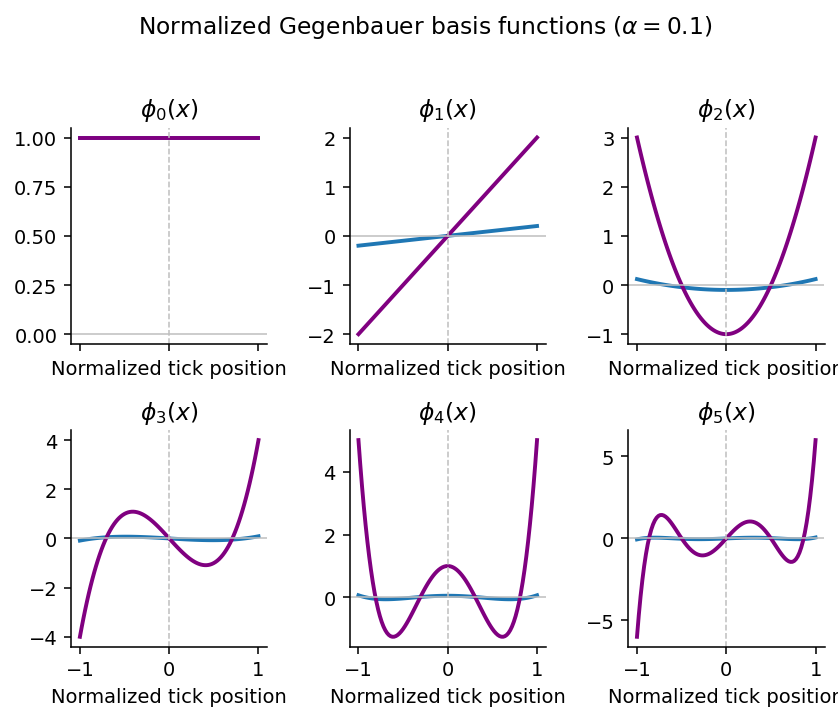

In [ ]:
# ---------------------------------------------------------------------
# 3. Plot the basis functions
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    2, 3,
    figsize=(6, 5),
    sharex=True
)

axes = axes.ravel()

for k, ax in enumerate(axes):
    if k <= 6:
        ax.plot(x, Phi[:, k], color="#1f77b4", lw=2)
        ax.plot(x, Phi1[:, k], color="purple", lw=2)
        ax.axvline(0, color="0.75", lw=0.8, ls="--")
        ax.axhline(0, color="0.75", lw=0.8)
        ax.set_title(rf"$\phi_{{{k}}}(x)$")
        ax.set_xlabel("Normalized tick position")
    else:
        ax.axis("off")

fig.suptitle(
    f"Normalized Gegenbauer basis functions ($\\alpha=0.1$)",
    y=1.02
)

fig.tight_layout()
plt.savefig("gegenbauer_basis_functions.png", bbox_inches="tight")
plt.show()

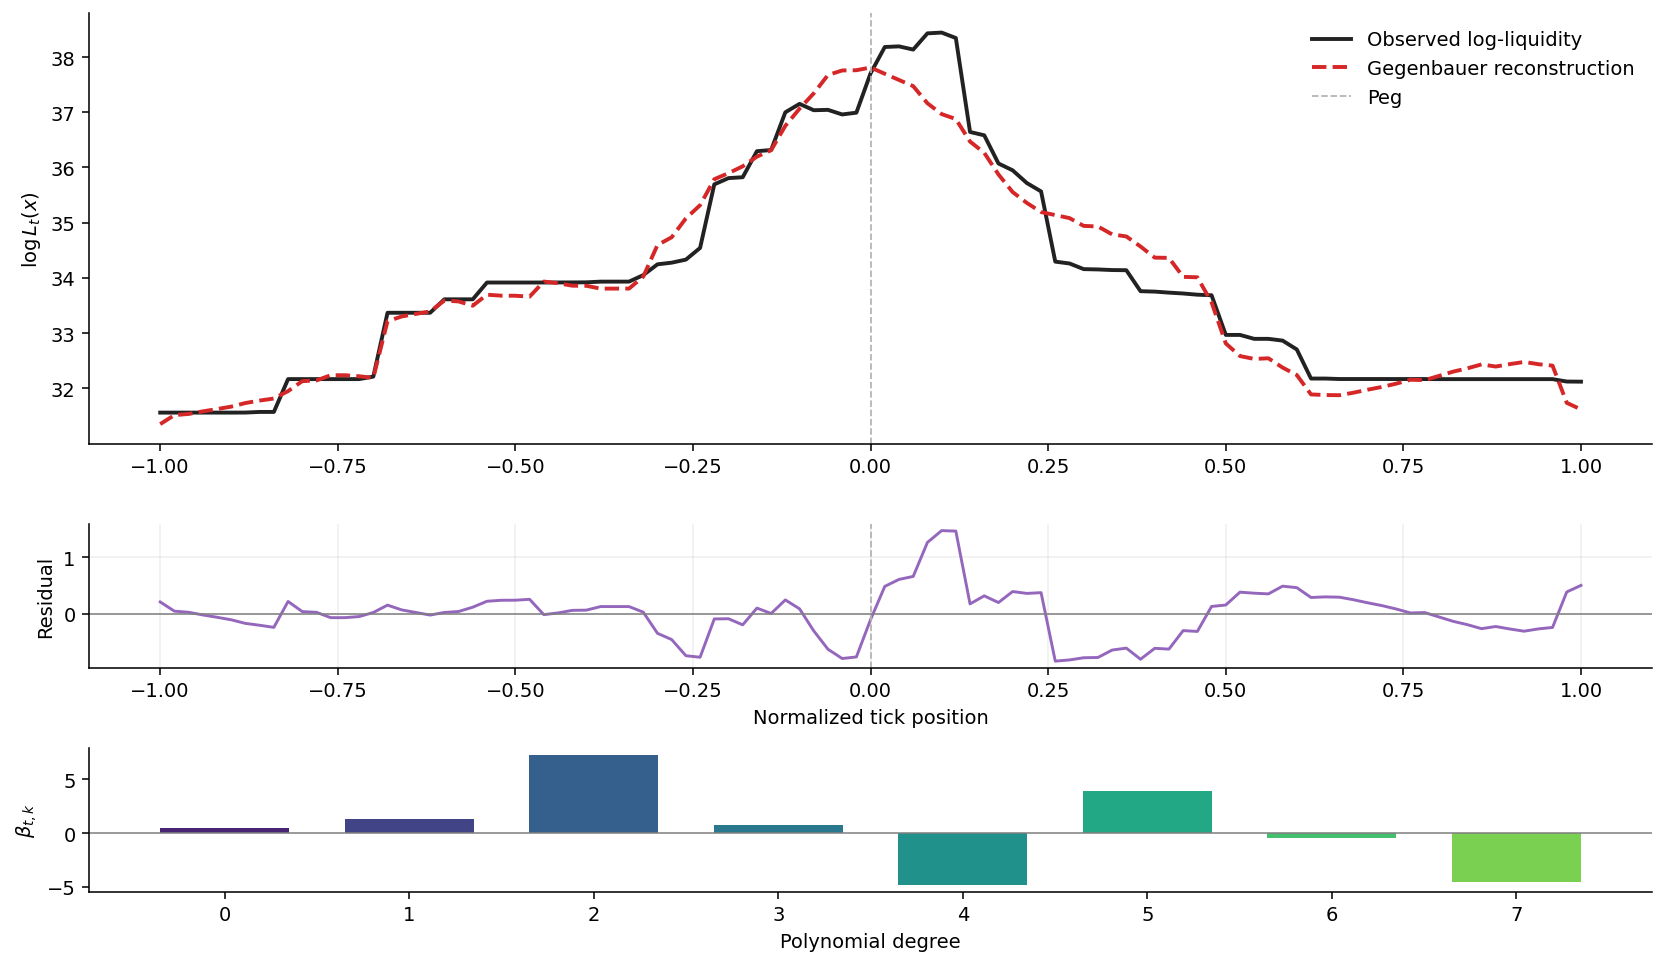

In [ ]:
# Select a representative curve.
# Replace with a specific timestamp if desired.
row_id = len(timestamps) - 2000

ts = timestamps[row_id]
observed = Y_obs[row_id]
fitted = Y_hat[row_id]
residual = observed - fitted

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 7),
    sharex=False,
    gridspec_kw={"height_ratios": [3, 1, 1]}
)

axes[0].plot(
    x,
    observed,
    color="#222222",
    lw=2,
    label="Observed log-liquidity"
)

axes[0].plot(
    x,
    fitted,
    color="#d62728",
    lw=2,
    ls="--",
    label="Gegenbauer reconstruction"
)

axes[0].axvline(
    0,
    color="0.7",
    lw=0.9,
    ls="--",
    label="Peg"
)

axes[0].set_ylabel(r"$\log L_t(x)$")
# axes[0].set_title(f"{ts}")
axes[0].legend(frameon=False)

ax = axes[1]
ax.plot(x, residual, color="#9467bd", lw=1.5)
ax.axhline(0, color="0.5", lw=0.8)
ax.axvline(0, color="0.7", lw=0.9, ls="--")
ax.set_xlabel("Normalized tick position")
ax.set_ylabel("Residual")
ax.grid(alpha=0.2)


axes[2].bar(
    np.arange(n_components),
    scores[row_id],
    color=colors,
    width=0.7
)

axes[2].axhline(0, color="0.5", lw=0.8)
axes[2].set_xlabel("Polynomial degree")
axes[2].set_ylabel(r"$\beta_{t,k}$")
axes[2].set_xticks(np.arange(n_components))


fig.tight_layout()
plt.savefig("gegenbauer_curve_reconstruction.png", bbox_inches="tight", transparent = True, dpi = 300)
plt.show()

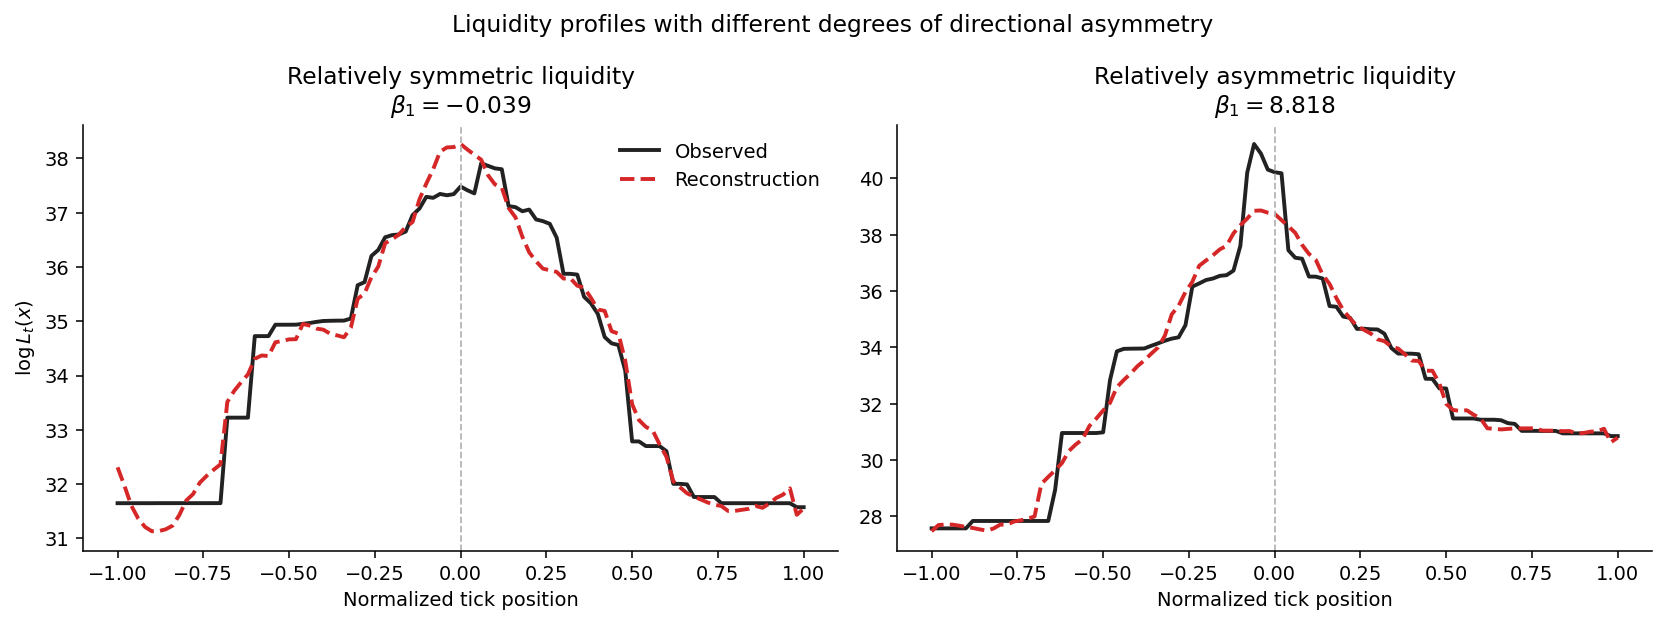

Symmetric example: 2025-01-04 08:00:00+00:00
Asymmetric example: 2023-03-03 04:00:00+00:00


In [ ]:
# Degree-one score as an asymmetry indicator
degree_one = scores[:, 1]

# Select observations from the lower and upper deciles of |beta_1|
abs_degree_one = np.abs(degree_one)

symmetric_candidates = np.where(
    abs_degree_one <= np.nanquantile(abs_degree_one, 0.10)
)[0]

asymmetric_candidates = np.where(
    abs_degree_one >= np.nanquantile(abs_degree_one, 0.90)
)[0]

idx_symmetric = symmetric_candidates[len(symmetric_candidates) // 2]
idx_asymmetric = asymmetric_candidates[len(asymmetric_candidates) // 2]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    sharey=False
)

for ax, idx, title in [
    (
        axes[0],
        idx_symmetric,
        "Relatively symmetric liquidity"
    ),
    (
        axes[1],
        idx_asymmetric,
        "Relatively asymmetric liquidity"
    ),
]:
    ax.plot(
        x,
        Y_obs[idx],
        color="#222222",
        lw=2,
        label="Observed"
    )

    ax.plot(
        x,
        Y_hat[idx],
        color="#d62728",
        lw=2,
        ls="--",
        label="Reconstruction"
    )

    ax.axvline(0, color="0.7", lw=0.9, ls="--")
    ax.set_xlabel("Normalized tick position")
    ax.set_title(
        f"{title}\n"
        rf"$\beta_1={scores[idx, 1]:.3f}$"
    )

axes[0].set_ylabel(r"$\log L_t(x)$")
axes[0].legend(frameon=False)

fig.suptitle(
    "Liquidity profiles with different degrees of directional asymmetry"
)
fig.tight_layout()
plt.savefig("symmetric_vs_asymmetric_liquidity.png", bbox_inches="tight", dpi = 300, transparent = True)
plt.show()

print("Symmetric example:", timestamps[idx_symmetric])
print("Asymmetric example:", timestamps[idx_asymmetric])

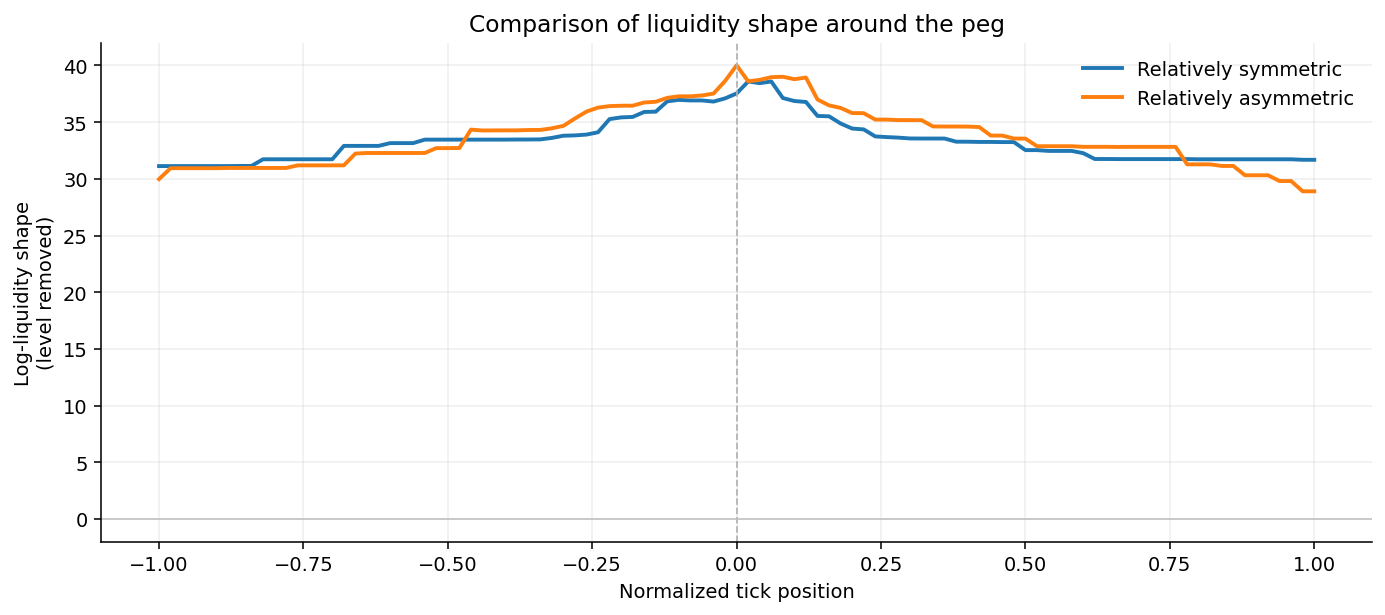

In [38]:
# Remove the degree-zero component to focus on shape rather than level.
# This assumes phi[:, 0] is the degree-zero basis function.
shape_symmetric = (
    Y_obs[idx_symmetric]
    - scores[idx_symmetric, 0] * Phi[:, 0]
)

shape_asymmetric = (
    Y_obs[idx_asymmetric]
    - scores[idx_asymmetric, 0] * Phi[:, 0]
)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(
    x,
    shape_symmetric,
    lw=2,
    label="Relatively symmetric"
)

ax.plot(
    x,
    shape_asymmetric,
    lw=2,
    label="Relatively asymmetric"
)

ax.axvline(0, color="0.7", lw=0.9, ls="--")
ax.axhline(0, color="0.75", lw=0.8)
ax.set_xlabel("Normalized tick position")
ax.set_ylabel("Log-liquidity shape\n(level removed)")
ax.set_title("Comparison of liquidity shape around the peg")
ax.legend(frameon=False)
ax.grid(alpha=0.2)

fig.tight_layout()
plt.savefig("liquidity_shape_comparison.png", bbox_inches="tight")
plt.show()

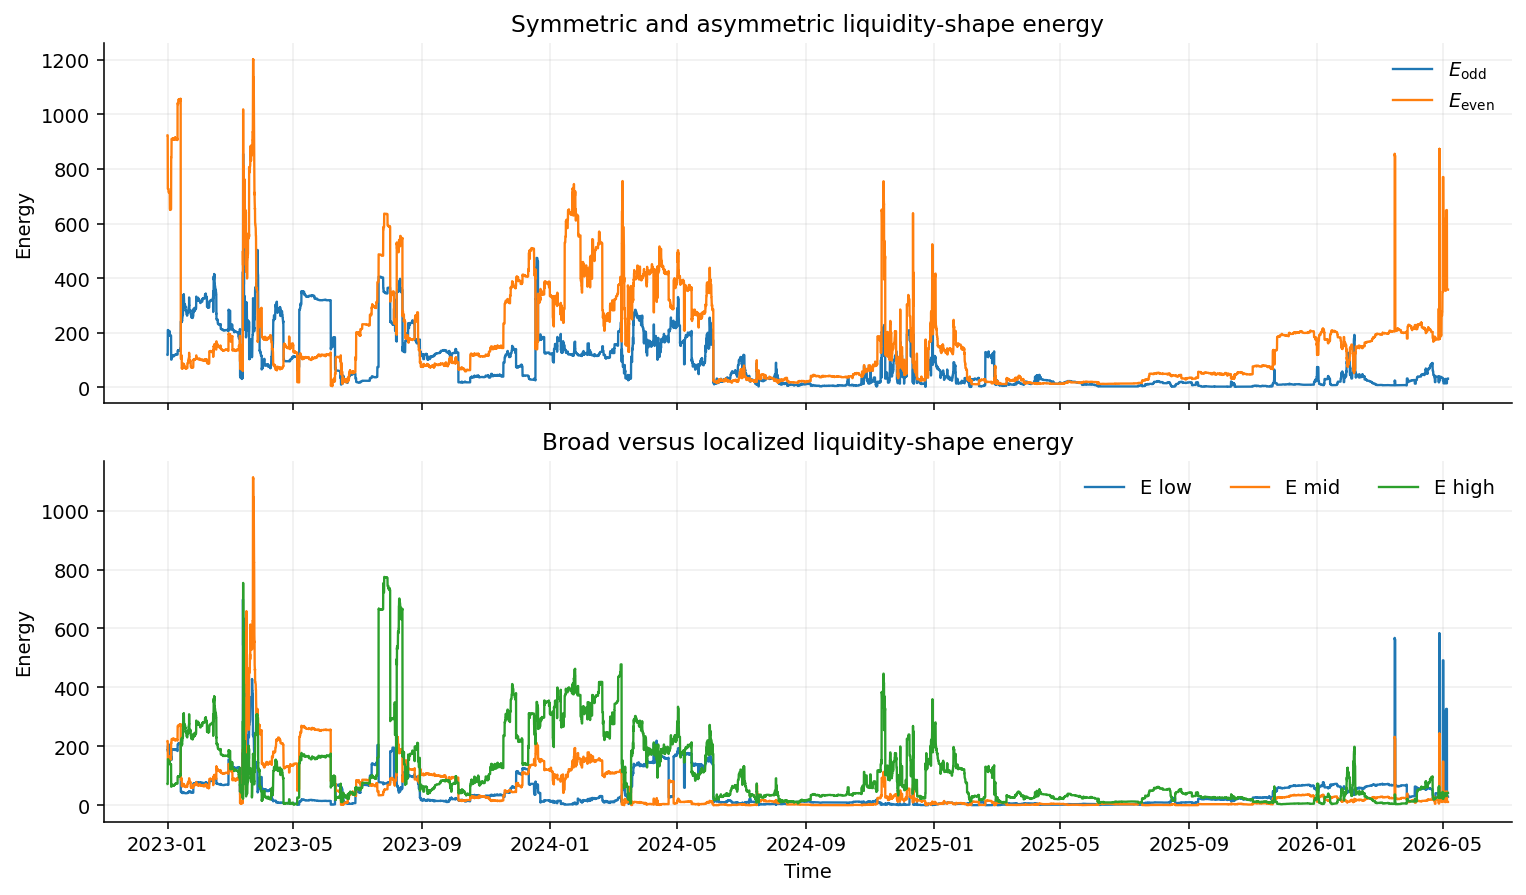

In [39]:
# ---------------------------------------------------------------------
# Energy features
# ---------------------------------------------------------------------

energy = pd.DataFrame(index=timestamps)

odd_idx = [k for k in range(1, n_components) if k % 2 == 1]
even_idx = [k for k in range(1, n_components) if k % 2 == 0]

energy["E_odd"] = np.sum(scores[:, odd_idx] ** 2, axis=1)
energy["E_even"] = np.sum(scores[:, even_idx] ** 2, axis=1)

low_idx = [k for k in [1, 2] if k < n_components]
mid_idx = [k for k in [3, 4] if k < n_components]
high_idx = [k for k in [5, 6, 7] if k < n_components]

energy["E_low"] = np.sum(scores[:, low_idx] ** 2, axis=1)
energy["E_mid"] = np.sum(scores[:, mid_idx] ** 2, axis=1)
energy["E_high"] = np.sum(scores[:, high_idx] ** 2, axis=1)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 6.5),
    sharex=True
)

axes[0].plot(
    energy.index,
    energy["E_odd"],
    lw=1.2,
    label=r"$E_{\mathrm{odd}}$"
)

axes[0].plot(
    energy.index,
    energy["E_even"],
    lw=1.2,
    label=r"$E_{\mathrm{even}}$"
)

axes[0].set_ylabel("Energy")
axes[0].set_title("Symmetric and asymmetric liquidity-shape energy")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

for col in ["E_low", "E_mid", "E_high"]:
    axes[1].plot(
        energy.index,
        energy[col],
        lw=1.2,
        label=col.replace("_", " ")
    )

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Energy")
axes[1].set_title("Broad versus localized liquidity-shape energy")
axes[1].legend(frameon=False, ncol=3)
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.savefig("gegenbauer_energy_features.png", bbox_inches="tight")
plt.show()

## Alpha value impact

In [12]:
def make_liquidity_matrix(
    df,
    value_col="logL",
    time_col="hour",
    x_col="tick_norm",
    resample_freq=None,
):
    """
    Returns matrix M with index=time, columns=tick_norm, values=log liquidity.
    """
    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col])

    M = (
        d.pivot_table(
            index=time_col,
            columns=x_col,
            values=value_col,
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )

    if resample_freq is not None:
        M = M.resample(resample_freq).mean()

    # Fill small gaps across ticks and time
    M = M.interpolate(axis=1, limit_direction="both")
    M = M.ffill().bfill()

    return M


M_peg = make_liquidity_matrix(d_pegcentered, resample_freq=None)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import eval_gegenbauer
from scipy.linalg import solve_triangular

def quadrature_widths(x):
    x = np.asarray(x, dtype=float)

    edges = np.zeros(len(x) + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = -1.0
    edges[-1] = 1.0

    return np.diff(edges)


def gegenbauer_weight_on_grid(x, alpha):
    """
    Gegenbauer weight:
        w_alpha(x) = (1 - x^2)^(alpha - 1/2)

    Endpoints are clipped to avoid infinite weights when alpha < 0.5.
    """
    x = np.asarray(x, dtype=float)
    dx = np.median(np.diff(np.sort(x)))
    eps = dx / 2

    x_eff = np.clip(x, -1 + eps, 1 - eps)
    w = (1.0 - x_eff**2) ** (alpha - 0.5)

    return w


def orthonormal_gegenbauer_basis(x, K, alpha):
    """
    Discrete weighted orthonormal Gegenbauer basis.
    """
    x = np.asarray(x, dtype=float)

    q = quadrature_widths(x)
    w = gegenbauer_weight_on_grid(x, alpha)

    mass = q * w
    mass = mass / mass.mean()

    Phi = np.column_stack([
        eval_gegenbauer(k, alpha, x)
        for k in range(K + 1)
    ])

    A = np.sqrt(mass)[:, None] * Phi
    Q, R = np.linalg.qr(A)

    B = solve_triangular(R.T, Phi.T, lower=True).T

    return B, mass


def weighted_gegenbauer_reconstruction(Y, x, K, alpha):
    B, mass = orthonormal_gegenbauer_basis(x, K, alpha)

    coeff = Y @ (mass[:, None] * B)
    recon = coeff @ B.T

    return recon, coeff, B

In [14]:
def infer_dt_hours(index):
    dt = np.diff(index.values).astype("timedelta64[s]").astype(float)
    return np.median(dt) / 3600.0


def score_temporal_roughness(scores):
    """
    Variance-weighted average RMS first-difference / std across score series.
    Lower means smoother score dynamics.
    """
    C = np.asarray(scores, dtype=float)

    std = np.std(C, axis=0) + 1e-12
    rms_diff = np.sqrt(np.mean(np.diff(C, axis=0) ** 2, axis=0))

    rough_per_score = rms_diff / std

    var = np.var(C, axis=0)
    weights = var / (var.sum() + 1e-12)

    return np.sum(weights * rough_per_score)


def score_high_frequency_power(scores, dt_hours=1.0, cutoff_hours=24.0):
    """
    Fraction of score spectral power at periods shorter than cutoff_hours.
    Lower means less high-frequency temporal noise.
    """
    C = np.asarray(scores, dtype=float)
    C = C - C.mean(axis=0, keepdims=True)

    T = C.shape[0]

    F = np.fft.rfft(C, axis=0)
    freqs = np.fft.rfftfreq(T, d=dt_hours)

    power = np.abs(F) ** 2

    valid = freqs > 0
    high = freqs >= 1.0 / cutoff_hours

    return power[high].sum() / (power[valid].sum() + 1e-12)


def effective_number_of_scores(scores):
    """
    Entropy-based effective number of active score components.
    Lower means variance is concentrated in fewer components.
    """
    C = np.asarray(scores, dtype=float)

    var = np.var(C, axis=0)
    p = var / (var.sum() + 1e-12)

    entropy = -np.sum(p * np.log(p + 1e-12))

    return np.exp(entropy)


def mean_abs_score_correlation(scores):
    """
    Mean absolute off-diagonal correlation between scores.
    Lower means less mixing/redundancy between score time series.
    """
    C = np.asarray(scores, dtype=float)

    if C.shape[1] <= 1:
        return np.nan

    C = C - C.mean(axis=0, keepdims=True)
    C = C / (C.std(axis=0, keepdims=True) + 1e-12)

    corr = np.corrcoef(C, rowvar=False)

    mask = ~np.eye(corr.shape[0], dtype=bool)

    return np.nanmean(np.abs(corr[mask]))

In [15]:
def alpha_tail_score_diagnostics(
    M_peg,
    alphas,
    K=10,
    tail_cut=0.75,
    center_cut=0.25,
    cutoff_hours=24.0,
    drop_level_score=True,
):
    x = M_peg.columns.astype(float).values

    Y = M_peg.values.astype(float)

    # Focus on spatial shape rather than total liquidity level
    Y = Y - Y.mean(axis=1, keepdims=True)

    tail_mask = np.abs(x) >= tail_cut
    center_mask = np.abs(x) <= center_cut

    dt_hours = infer_dt_hours(M_peg.index)

    rows = []

    for alpha in alphas:
        recon, coeff, B = weighted_gegenbauer_reconstruction(
            Y,
            x,
            K=K,
            alpha=alpha,
        )

        resid = Y - recon

        tail_rmse = np.sqrt(np.mean(resid[:, tail_mask] ** 2))
        center_rmse = np.sqrt(np.mean(resid[:, center_mask] ** 2))
        all_rmse = np.sqrt(np.mean(resid ** 2))

        if drop_level_score:
            scores = coeff[:, 1:]
        else:
            scores = coeff

        roughness = score_temporal_roughness(scores)

        hf_power = score_high_frequency_power(
            scores,
            dt_hours=dt_hours,
            cutoff_hours=cutoff_hours,
        )

        n_eff = effective_number_of_scores(scores)

        mean_abs_corr = mean_abs_score_correlation(scores)

        rows.append({
            "alpha": alpha,
            "tail_rmse": tail_rmse,
            "center_rmse": center_rmse,
            "all_rmse": all_rmse,
            "score_roughness": roughness,
            "score_hf_power": hf_power,
            "effective_scores": n_eff,
            "mean_abs_score_corr": mean_abs_corr,
        })

    out = pd.DataFrame(rows)

    # Normalize by alpha = 0.5 for publication-friendly comparison
    ref_idx = (out["alpha"] - 0.5).abs().idxmin()
    ref = out.loc[ref_idx]

    for col in [
        "tail_rmse",
        "center_rmse",
        "all_rmse",
        "score_roughness",
        "score_hf_power",
        "effective_scores",
        "mean_abs_score_corr",
    ]:
        out[col + "_rel"] = out[col] / ref[col]

    return out

In [18]:
def alpha_rmse_and_score_variance_diagnostics(
    M_peg,
    alphas,
    K=10,
    tail_cut=0.75,
    center_cut=0.25,
    degrees_to_show=range(0, 7),
    use_shape_demeaned=True,
):
    x = M_peg.columns.astype(float).values
    Y = M_peg.values.astype(float)

    if use_shape_demeaned:
        Y = Y - Y.mean(axis=1, keepdims=True)

    tail_mask = np.abs(x) >= tail_cut
    center_mask = np.abs(x) <= center_cut

    rmse_rows = []
    variance_rows = []

    for alpha in alphas:
        recon, coeff, B = weighted_gegenbauer_reconstruction(
            Y,
            x,
            K=K,
            alpha=alpha,
        )

        resid = Y - recon

        all_rmse = np.sqrt(np.mean(resid ** 2))
        tail_rmse = np.sqrt(np.mean(resid[:, tail_mask] ** 2))
        center_rmse = np.sqrt(np.mean(resid[:, center_mask] ** 2))

        rmse_rows.append({
            "alpha": alpha,
            "all_rmse": all_rmse,
            "tail_rmse": tail_rmse,
            "center_rmse": center_rmse,
        })

        # Variance share of each Gegenbauer score
        score_var = np.var(coeff, axis=0)
        total_var = score_var.sum() + 1e-12
        score_var_share = score_var / total_var

        for degree in degrees_to_show:
            if degree <= K:
                variance_rows.append({
                    "alpha": alpha,
                    "degree": degree,
                    "variance_share": score_var_share[degree],
                })

    rmse_df = pd.DataFrame(rmse_rows)
    variance_df = pd.DataFrame(variance_rows)

    # Normalize RMSE relative to alpha = 0.5
    ref_idx = (rmse_df["alpha"] - 0.5).abs().idxmin()
    ref = rmse_df.loc[ref_idx]

    for col in ["all_rmse", "tail_rmse", "center_rmse"]:
        rmse_df[col + "_rel"] = rmse_df[col] / ref[col]

    return rmse_df, variance_df

def _centers_to_edges(values):
    """
    Convert sorted coordinate centers to plotting edges for pcolormesh.
    """
    values = np.asarray(values, dtype=float)

    if len(values) == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5])

    mids = 0.5 * (values[:-1] + values[1:])
    first = values[0] - (mids[0] - values[0])
    last = values[-1] + (values[-1] - mids[-1])

    return np.r_[first, mids, last]

from matplotlib.colors import TwoSlopeNorm


def plot_alpha_tail_rmse_variance_summary(
    M_peg,
    alphas=np.linspace(0.15, 1.5, 120),
    selected_alphas=(0.25, 0.5, 0.75, 1.25),
    K=10,
    tail_cut=0.75,
    center_cut=0.25,
    degrees_to_show=range(0, 7),
    rmse_alpha_interval=None,
    use_shape_demeaned=True,
    save_path=None,
):
    """
    Summary figure:
      1. Gegenbauer weight profiles.
      2. Tail/centre/overall RMSE tradeoff on log y-scale.
      3. Variance share matrix by degree and alpha.

    Parameters
    ----------
    rmse_alpha_interval : tuple or None
        If tuple, e.g. (0.2, 0.8), only this alpha interval is shown
        in the middle RMSE panel.
    degrees_to_show : iterable
        Degrees displayed in the variance-share heatmap.
        Use range(0, 7) for degrees 0,...,6.
        Use range(1, 8) to exclude the level mode and show degrees 1,...,7.
    """
    x = M_peg.columns.astype(float).values

    rmse_df, variance_df = alpha_rmse_and_score_variance_diagnostics(
        M_peg,
        alphas=alphas,
        K=K,
        tail_cut=tail_cut,
        center_cut=center_cut,
        degrees_to_show=degrees_to_show,
        use_shape_demeaned=use_shape_demeaned,
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17.5, 4.8),
        gridspec_kw={"width_ratios": [1.05, 1.1, 1.25]},
    )

    # --------------------------------------------------
    # Panel 1: weight profiles
    # --------------------------------------------------
    ax = axes[0]

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_alphas)))

    for alpha, c in zip(selected_alphas, colors):
        w = gegenbauer_weight_on_grid(x, alpha)
        w = w / np.mean(w)

        ax.plot(
            x,
            w,
            lw=2,
            color=c,
            label=fr"$\alpha={alpha}$",
        )

    ax.axvspan(-1, -tail_cut, color="royalblue", alpha=0.12)
    ax.axvspan(tail_cut, 1, color="royalblue", alpha=0.12)
    ax.axvspan(-center_cut, center_cut, color="crimson", alpha=0.12)

    ax.axvline(0, color="black", lw=1, ls=":")
    ax.set_title("Spatial weight profile")
    ax.set_xlabel("Peg-centered normalized tick")
    ax.set_ylabel(r"Normalized $w_\alpha(x)$")
    ax.legend(frameon=False)
    # ax.grid(alpha=0.25)

    # --------------------------------------------------
    # Panel 2: RMSE tradeoff, log y-scale
    # --------------------------------------------------
    ax = axes[1]

    if rmse_alpha_interval is not None:
        lo, hi = rmse_alpha_interval
        rmse_plot = rmse_df[
            (rmse_df["alpha"] >= lo) &
            (rmse_df["alpha"] <= hi)
        ].copy()
    else:
        rmse_plot = rmse_df.copy()

    ax.plot(
        rmse_plot["alpha"],
        rmse_plot["tail_rmse_rel"],
        lw=2.5,
        color="royalblue",
        label="Tail RMSE",
    )

    ax.plot(
        rmse_plot["alpha"],
        rmse_plot["center_rmse_rel"],
        lw=2.5,
        color="crimson",
        label="Centre RMSE",
    )

    ax.plot(
        rmse_plot["alpha"],
        rmse_plot["all_rmse_rel"],
        lw=2.0,
        ls="--",
        color="tab:green",
        label="Overall RMSE",
    )

    ax.axhline(1.0, color="black", lw=1, ls="--")
    ax.axvline(0.5, color="black", lw=1, ls=":")

    ax.set_yscale("log")

    ax.set_title(fr"Reconstruction tradeoff, $K={K}$")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"RMSE relative to $\alpha=0.5$")

    if rmse_alpha_interval is not None:
        ax.set_xlim(rmse_alpha_interval)

    ax.legend(frameon=False)
    # ax.grid(alpha=0.25, which="both")

    # --------------------------------------------------
    # Panel 3: variance share matrix
    # --------------------------------------------------
    ax = axes[2]

    V = (
        variance_df
        .pivot(index="degree", columns="alpha", values="variance_share")
        .sort_index()
        .sort_index(axis=1)
    )

    degree_vals = V.index.values.astype(float)
    alpha_vals = V.columns.values.astype(float)

    degree_edges = _centers_to_edges(degree_vals)
    alpha_edges = _centers_to_edges(alpha_vals)



    Z = 100.0 * V.values
    norm = TwoSlopeNorm(
        vmin=np.nanpercentile(Z, 2),
        vcenter=np.nanmedian(Z),
        vmax=np.nanpercentile(Z, 98),
    )

    # mesh = ax.pcolormesh(
    #     alpha_edges,
    #     degree_edges,
    #     Z,
    #     cmap="coolwarm",
    #     norm=norm,
    #     shading="auto",
    # )
    
    mesh = ax.pcolormesh(
        alpha_edges,
        degree_edges,
        Z,
        cmap="coolwarm",
        shading="auto",
    )

    ax.axvline(0.5, color="black", lw=1.2, ls=":")

    ax.set_title("Score variance share by degree")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Gegenbauer degree")

    ax.set_xticks(np.round(np.linspace(alpha_vals.min(), alpha_vals.max(), 6), 2))
    ax.set_yticks(degree_vals)

    cbar = fig.colorbar(mesh, ax=ax, shrink=0.9)
    cbar.set_label("Variance share (%)")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, transparent = True, bbox_inches="tight")

    plt.show()

    return rmse_df, variance_df

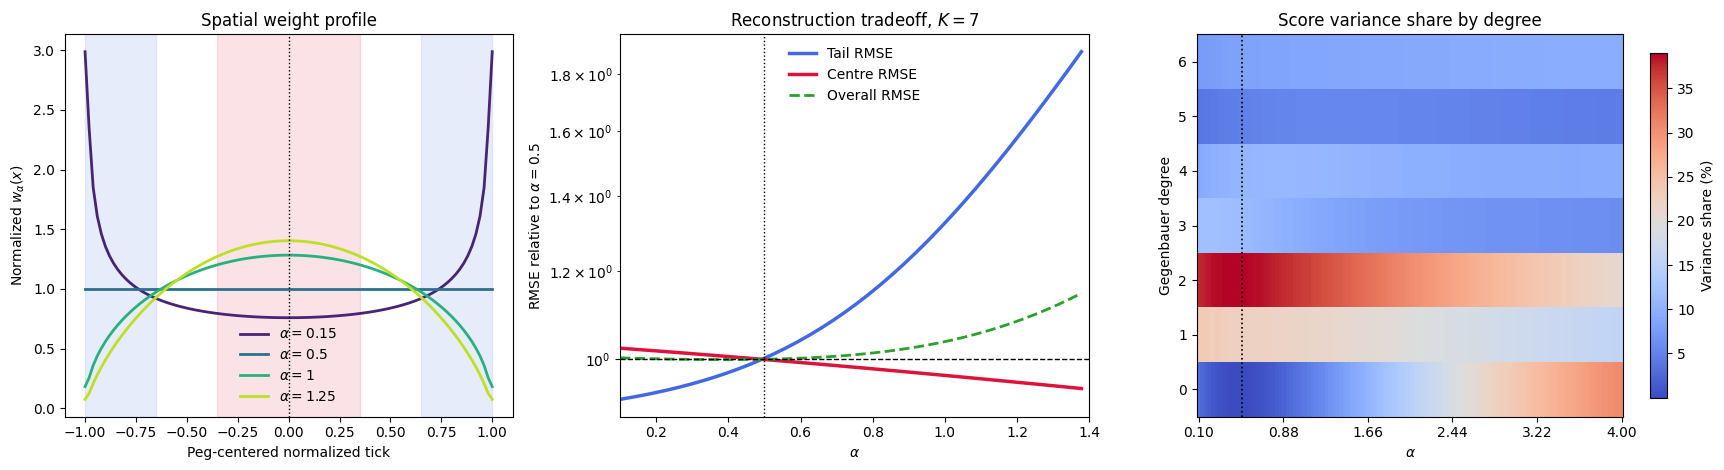

In [19]:
rmse_alpha, variance_alpha = plot_alpha_tail_rmse_variance_summary(
    M_peg,
    alphas=np.linspace(0.1, 4., 120),
    selected_alphas=(0.15, 0.5, 1, 1.25),
    K=7,
    tail_cut=0.65,
    center_cut=0.35,
    degrees_to_show=range(0, 7),
    rmse_alpha_interval=(0.1, 1.4),
    use_shape_demeaned=True,
    save_path='alpha_impact_decomposition.png',
)